# 04 - Inferential Statistics: t-test, ANOVA, Correlation


## 1) Learning Objectives

- Explain hypothesis-testing workflow.
- Interpret p-values correctly.
- Compute and explain correlation.
- Apply t-test (2 groups) and ANOVA (3 groups).

## 2) Why This Topic Matters

Statistics starts with understanding your data. If we skip inspection or mix up variable types, later analysis can become misleading.

## 3) Short and Simple Theory Explanation

- **Hypothesis:** a testable statement about data.
- **H0 (null):** no difference / no relationship.
- **H1 (alternative):** difference or relationship exists.
- **p-value:** probability of seeing data this extreme if H0 were true.
- **t-test:** compares means of two groups.
- **ANOVA:** compares means across three or more groups.
- **Correlation:** measures linear association; it does not prove causation.

## 4) Step-by-Step Code Examples

### Step 4.1 — Import tools

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_theme(style='whitegrid')
rng = np.random.default_rng(42)

### Step 4.2 — Synthetic two-group dataset for t-test

In [2]:
group_a_scores = rng.normal(loc=72, scale=8, size=40)
group_b_scores = rng.normal(loc=78, scale=8, size=40)

ttest_data = pd.DataFrame({
    'score': np.concatenate([group_a_scores, group_b_scores]),
    'method': ['Method A'] * 40 + ['Method B'] * 40,
})

ttest_data.groupby('method')['score'].agg(['mean', 'std', 'count']).round(2)

,mean,std,count
method,,,
Method A,72.31,6.61,40
Method B,78.11,5.84,40


**Interpretation:** Method B has a higher sample mean, but we still ask whether the difference is statistically meaningful.

### Step 4.3 — Independent two-sample t-test

In [3]:
scores_a = ttest_data.loc[ttest_data['method'] == 'Method A', 'score']
scores_b = ttest_data.loc[ttest_data['method'] == 'Method B', 'score']

t_statistic, p_value = stats.ttest_ind(scores_a, scores_b, equal_var=False)
print('t statistic:', round(t_statistic, 3))
print('p-value:', round(p_value, 4))

if p_value < 0.05:
    print('At alpha = 0.05, we reject H0: groups appear different on average.')
else:
    print('At alpha = 0.05, we do not reject H0: difference may be due to chance.')

t statistic: -4.16
p-value: 0.0001
At alpha = 0.05, we reject H0: groups appear different on average.


**What is `stats.ttest_ind`?** It runs an independent two-sample t-test and returns a test statistic and p-value.

### Step 4.4 — Synthetic three-group dataset for ANOVA

In [4]:
anova_data = pd.DataFrame({
    'score': np.concatenate([
        rng.normal(70, 7, 35),
        rng.normal(75, 7, 35),
        rng.normal(82, 7, 35),
    ]),
    'program': ['Program 1'] * 35 + ['Program 2'] * 35 + ['Program 3'] * 35,
})

anova_data.groupby('program')['score'].mean().round(2)

program
Program 1    67.92
Program 2    75.15
Program 3    82.00
Name: score, dtype: float64

In [5]:
group1 = anova_data.loc[anova_data['program'] == 'Program 1', 'score']
group2 = anova_data.loc[anova_data['program'] == 'Program 2', 'score']
group3 = anova_data.loc[anova_data['program'] == 'Program 3', 'score']

f_statistic, p_value_anova = stats.f_oneway(group1, group2, group3)
print('F statistic:', round(f_statistic, 3))
print('p-value:', round(p_value_anova, 4))

F statistic: 41.039
p-value: 0.0


**Interpretation:** A small p-value suggests at least one group mean differs, but ANOVA does not tell us which pair differs.

### Step 4.5 — Correlation between two numerical variables

Pearson correlation: 0.879


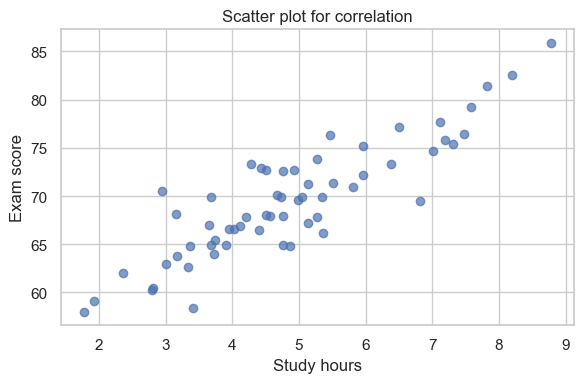

In [6]:
study_hours = rng.normal(5, 1.5, 60)
exam_scores = 50 + 4 * study_hours + rng.normal(0, 3, 60)
correlation_data = pd.DataFrame({'study_hours': study_hours, 'exam_score': exam_scores})

correlation_value = correlation_data['study_hours'].corr(correlation_data['exam_score'])
print('Pearson correlation:', round(correlation_value, 3))

plt.figure(figsize=(6, 4))
plt.scatter(correlation_data['study_hours'], correlation_data['exam_score'], alpha=0.7)
plt.xlabel('Study hours')
plt.ylabel('Exam score')
plt.title('Scatter plot for correlation')
plt.tight_layout()
plt.show()

**Interpretation:** Positive correlation means higher study hours tend to appear with higher scores. This does **not** prove that study hours alone cause higher scores.

### Step 4.6 — Change noise level and observe p-value

In [7]:
def run_ttest(mean_diff, noise_level):
    a = rng.normal(70, noise_level, 40)
    b = rng.normal(70 + mean_diff, noise_level, 40)
    _, p = stats.ttest_ind(a, b, equal_var=False)
    return p

p_demo = pd.DataFrame({
    'mean_difference': [0, 2, 8],
    'noise_level': [8, 8, 8],
    'p_value': [run_ttest(0, 8), run_ttest(2, 8), run_ttest(8, 8)],
}).round(4)
p_demo

,mean_difference,noise_level,p_value
0,0,8,0.5664
1,2,8,0.0647
2,8,8,0.0000


**Interpretation:** Larger true differences and lower noise usually produce smaller p-values. A p-value is not proof of importance or causation.

## 7) Summary Interpretation

We practiced t-tests, ANOVA, and correlation on synthetic data and interpreted p-values carefully.

## 8) Student Check Questions

1. (Conceptual) What does a p-value tell us?

2. (Code) Set noise level to 20 and check how the p-value changes.

In [8]:
# Question 2 — your code here


## 9) Key Takeaways

- State H0 and H1 before testing.
- Choose the test that matches your question and number of groups.
- Report effect size and context, not only p-values.
- Correlation is not causation.

## 10) Optional Short Practice / Challenge

Run `stats.pearsonr` and compare with `.corr()`.

## 11) Code Refinement Tasks

Edit the code, rerun each cell, and write one short sentence per task.

1. Set `noise_level=20` in the t-test demo.
2. Use group means 72 vs 73 and rerun the t-test.

In [9]:
# Refinement 1


In [10]:
# Refinement 2


In [11]:
print('Notebook 04 completed successfully.')

Notebook 04 completed successfully.
